In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## Dataset Description

* The data files train.csv and test.csv contain gray-scale images of hand-drawn digits, from zero through nine.

* Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255, inclusive.

* The training data set, (train.csv), has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image.

* Each pixel column in the training set has a name like pixelx, where x is an integer between 0 and 783, inclusive. To locate this pixel on the image, suppose that we have decomposed x as x = i * 28 + j, where i and j are integers between 0 and 27, inclusive. Then pixelx is located on row i and column j of a 28 x 28 matrix, (indexing by zero).

* For example, pixel31 indicates the pixel that is in the fourth column from the left, and the second row from the top, as in the ascii-diagram below.

* Visually, if we omit the "pixel" prefix, the pixels make up the image like this:

000 001 002 003 ... 026 027

028 029 030 031 ... 054 055

056 057 058 059 ... 082 083

 |   |   |   |  ...  |   |
 
728 729 730 731 ... 754 755

756 757 758 759 ... 782 783 


* The test data set, (test.csv), is the same as the training set, except that it does not contain the "label" column.

* Your submission file should be in the following format: For each of the 28000 images in the test set, output a single line containing the ImageId and the digit you predict. For example, if you predict that the first image is of a 3, the second image is of a 7, and the third image is of a 8, then your submission file would look like:

ImageId,Label

1,3

2,7

3,8 

(27997 more lines)

* The evaluation metric for this contest is the categorization accuracy, or the proportion of test images that are correctly classified. For example, a categorization accuracy of 0.97 indicates that you have correctly classified all but 3% of the images.

## Veri Kümesi Açıklaması

* Train.csv ve test.csv veri dosyaları, sıfırdan dokuza kadar elle çizilmiş rakamların gri ölçekli resimlerini içerir.

* Her görsel 28 piksel yükseklik ve 28 piksel genişlik olmak üzere toplam 784 pikseldir. Her piksel, kendisiyle ilişkili tek bir piksel değerine sahiptir ve bu pikselin açıklığını veya koyuluğunu gösterir; daha yüksek sayılar daha koyu anlamına gelir. Bu piksel değeri, 0 ile 255 dahil, arasında bir tamsayıdır.

* Eğitim veri seti (train.csv), 785 sütuna sahiptir. "Etiket" olarak adlandırılan ilk sütun, kullanıcı tarafından çizilen rakamdır. Sütunların geri kalanı, ilişkili görüntünün piksel değerlerini içerir.

* Eğitim setindeki her piksel sütununun, x'in 0 ile 783 (dahil) arasında bir tam sayı olduğu pikselx gibi bir adı vardır. Görüntüde bu pikseli bulmak için, x'i x = i * 28 + j olarak ayrıştırdığımızı varsayalım; burada i ve j, 0 ile 27 (dahil) arasında tam sayılardır. Daha sonra pikselx, 28 x 28'lik bir matrisin i satırında ve j sütununda bulunur (sıfır indeksleme).

* Örneğin, pixel31, aşağıdaki ascii diyagramında olduğu gibi soldan dördüncü sütunda ve üstten ikinci satırda bulunan pikseli gösterir.

* Görsel olarak, "piksel" ön ekini atlarsak, pikseller görüntüyü şu şekilde oluşturur:

000 001 002 003 ... 026 027

028 029 030 031 ... 054 055

056 057 058 059 ... 082 083

 |   |   |   |  ...  |   |
 
728 729 730 731 ... 754 755

756 757 758 759 ... 782 783 

* Test veri seti (test.csv), "etiket" sütununu içermemesi dışında eğitim seti ile aynıdır.

* Gönderim dosyanız aşağıdaki formatta olmalıdır: Test setindeki 28000 görüntünün her biri için, ImageId'yi ve tahmin ettiğiniz rakamı içeren tek bir satır çıktısı alın. Örneğin, ilk görüntünün 3, ikinci görüntünün 7 ve üçüncü görüntünün 8 olduğunu tahmin ederseniz, gönderim dosyanız şöyle görünür:

ImageId,Label

1,3

2,7

3,8 

(27997 more lines)

* Bu yarışma için değerlendirme ölçütü, sınıflandırma doğruluğu veya doğru şekilde sınıflandırılan test görüntülerinin oranıdır. Örneğin, 0,97'lik bir sınıflandırma doğruluğu, görüntülerin %3'ü dışında tümünü doğru şekilde sınıflandırdığınızı gösterir.

## 1.Libraries

In [1]:
# load the libraries

In [2]:
import keras 
import tensorflow
from keras.models import Sequential,save_model,load_model
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from keras import backend as K
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 2.Data Load

In [3]:
# load data

In [4]:
df_train=pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df_train.shape

(42000, 785)

In [6]:
df_test=pd.read_csv("/kaggle/input/digit-recognizer/test.csv")
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df_test.shape

(28000, 784)

## 3.EDA

In [8]:
X_train = df_train.drop(["label"],axis = 1) 
y_train = df_train["label"]


In [9]:
# value counts 

In [10]:
y_train.value_counts()

1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: label, dtype: int64

In [11]:
#  Normalization

In [12]:
X_train = X_train / 255.0
test = df_test / 255.0
print("x_train shape: ",X_train.shape)
print("test shape: ",test.shape)

x_train shape:  (42000, 784)
test shape:  (28000, 784)


In [13]:
# reshape

In [14]:
X_train = X_train.values.reshape(-1,28,28,1)
test = test.values.reshape(-1,28,28,1)
print("x_train shape: ",X_train.shape)
print("test shape: ",test.shape)

x_train shape:  (42000, 28, 28, 1)
test shape:  (28000, 28, 28, 1)


In [15]:
# Label Encoding

In [16]:
from keras.utils import to_categorical

In [17]:
y_train=to_categorical(y_train,num_classes=10)

In [19]:
# train-test split

In [76]:
# test size %15 and train size %85

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X_train,y_train,test_size=0.15,random_state=3)

In [21]:
X_train.shape

(35700, 28, 28, 1)

In [22]:
y_train.shape

(35700, 10)

In [23]:
X_test.shape

(6300, 28, 28, 1)

In [24]:
y_test.shape

(6300, 10)

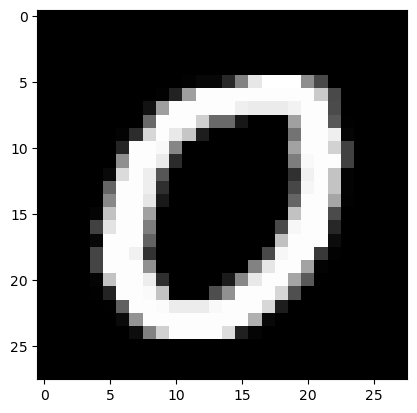

In [25]:
plt.imshow(X_train[2],cmap='gray')

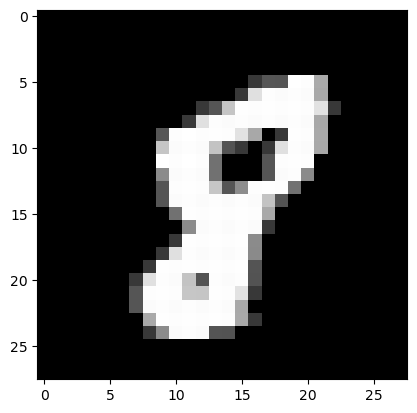

In [55]:
plt.imshow(X_train[1142],cmap='gray')

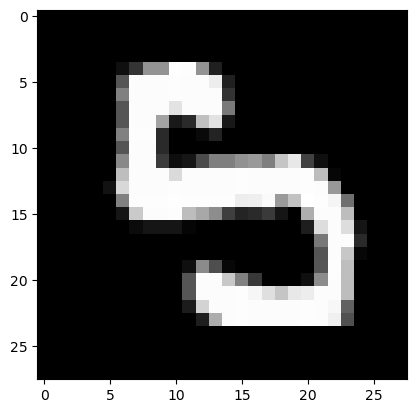

In [58]:
plt.imshow(X_test[48],cmap='gray')

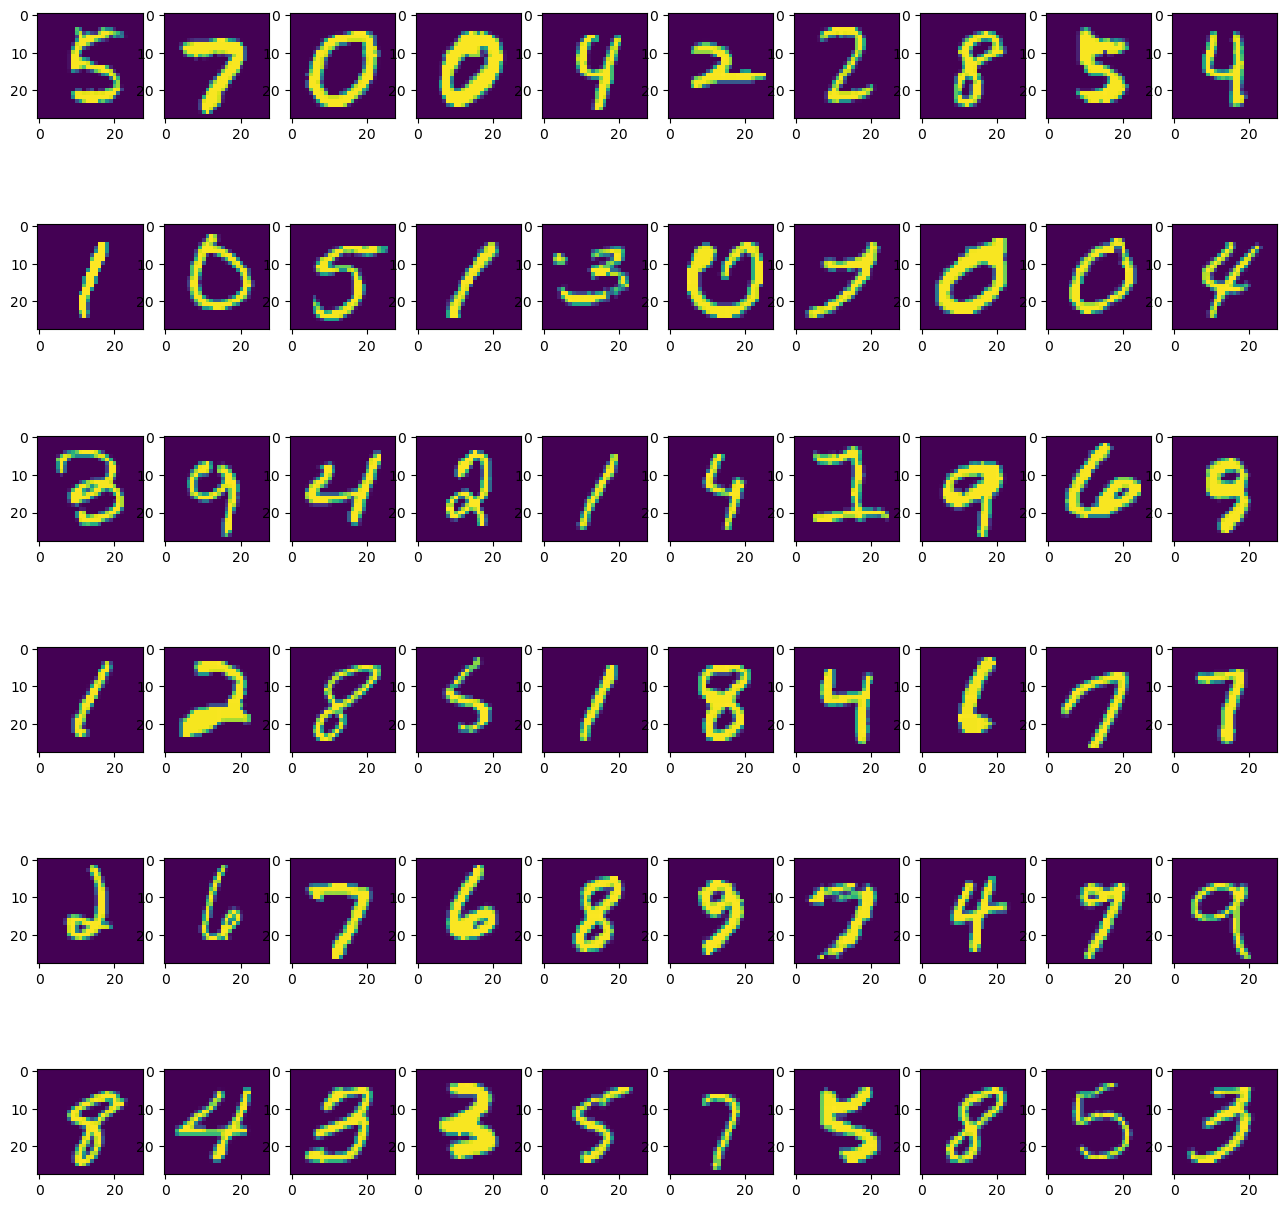

In [26]:
plt.figure(figsize=(16,16))
for i in range(60): 
    plt.subplot(6,10,i+1)
    plt.imshow(X_train[i])

## 

# CNN Training

In [27]:
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation="relu"))
model.add(Conv2D(64,kernel_size=(3,3),activation="relu"))
model.add(Conv2D(128,kernel_size=(3,3),activation="relu"))
model.add(Flatten())
model.add(Dense(10,activation="softmax"))

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 conv2d_2 (Conv2D)           (None, 9, 9, 64)          36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 7, 7, 128)         73856     
                                                                 
 flatten (Flatten)           (None, 6272)              0         
                                                        

In [29]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [30]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=15)

Epoch 1/15
1116/1116 [==============================] - 15s 5ms/step - loss: 0.1527 - accuracy: 0.9523 - val_loss: 0.0590 - val_accuracy: 0.9821
Epoch 2/15
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0476 - accuracy: 0.9854 - val_loss: 0.0524 - val_accuracy: 0.9824
Epoch 3/15
1116/1116 [==============================] - 5s 5ms/step - loss: 0.0320 - accuracy: 0.9900 - val_loss: 0.0476 - val_accuracy: 0.9838
Epoch 4/15
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0242 - accuracy: 0.9927 - val_loss: 0.0648 - val_accuracy: 0.9830
Epoch 5/15
1116/1116 [==============================] - 6s 6ms/step - loss: 0.0207 - accuracy: 0.9932 - val_loss: 0.0395 - val_accuracy: 0.9894
Epoch 6/15
1116/1116 [==============================] - 5s 5ms/step - loss: 0.0148 - accuracy: 0.9952 - val_loss: 0.0594 - val_accuracy: 0.9835
Epoch 7/15
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0125 - accuracy: 0.9960 - val_loss: 0.0462 - val_accuracy

In [35]:
# 2

model2=Sequential()

model2.add(Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.3))
model2.add(Conv2D(64,kernel_size=(3,3),activation="relu"))
model2.add(Dropout(0.3))
model2.add(Conv2D(64,kernel_size=(3,3),activation="relu"))
model2.add(Dropout(0.3))
model2.add(Conv2D(128,kernel_size=(3,3),activation="relu"))
model2.add(Dropout(0.3))
model2.add(Flatten())
model2.add(Dense(10,activation="softmax"))

In [38]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 dropout (Dropout)           (None, 13, 13, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 dropout_1 (Dropout)         (None, 11, 11, 64)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 9, 9, 64)          36928     
                                                      

In [39]:
model2.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [40]:
history=model2.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10)
history

Epoch 1/10


2023-03-19 14:56:42.745595: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1116/1116 [==============================] - 8s 5ms/step - loss: 0.1963 - accuracy: 0.9367 - val_loss: 0.0757 - val_accuracy: 0.9760
Epoch 2/10
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0669 - accuracy: 0.9788 - val_loss: 0.0577 - val_accuracy: 0.9825
Epoch 3/10
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0512 - accuracy: 0.9837 - val_loss: 0.0460 - val_accuracy: 0.9848
Epoch 4/10
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0404 - accuracy: 0.9873 - val_loss: 0.0429 - val_accuracy: 0.9863
Epoch 5/10
1116/1116 [==============================] - 6s 6ms/step - loss: 0.0386 - accuracy: 0.9880 - val_loss: 0.0359 - val_accuracy: 0.9886
Epoch 6/10
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0338 - accuracy: 0.9892 - val_loss: 0.0425 - val_accuracy: 0.9852
Epoch 7/10
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0281 - accuracy: 0.9912 - val_loss: 0.0385 - val_accuracy: 0.9873
Epo

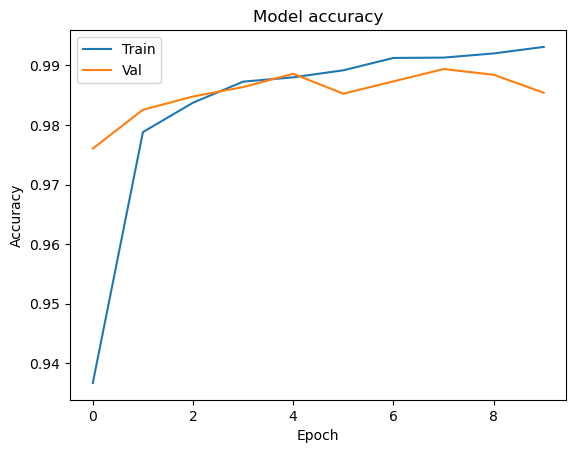

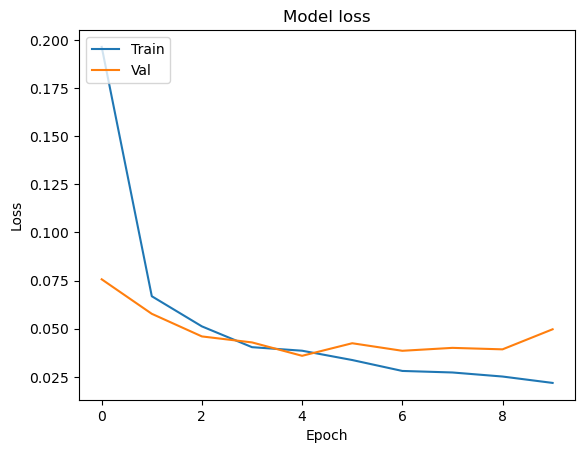

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [42]:
# slight overfitting but overall good results
# ufakta olsa overfitting var ama genel olarak iyi sonuçlar verdi

In [62]:
# 3

model3=Sequential()

model3.add(Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))
model3.add(MaxPooling2D(pool_size=(2,2)))
model3.add(Dropout(0.3))
model3.add(Conv2D(64,kernel_size=(3,3),activation="relu"))
model3.add(Dropout(0.3))
model3.add(Conv2D(64,kernel_size=(3,3),activation="relu"))
model3.add(Dropout(0.3))
model3.add(Conv2D(128,kernel_size=(3,3),activation="relu"))
model3.add(Dropout(0.3))
model3.add(Flatten())
model3.add(Dense(32, activation = "relu"))
model3.add(Dense(10,activation="softmax"))

In [63]:
model3.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 dropout_16 (Dropout)        (None, 13, 13, 32)        0         
                                                                 
 conv2d_21 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 dropout_17 (Dropout)        (None, 11, 11, 64)        0         
                                                                 
 conv2d_22 (Conv2D)          (None, 9, 9, 64)          36928     
                                                      

In [64]:
model3.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [51]:
history2=model3.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=8)
history2

Epoch 1/8


2023-03-19 15:09:15.212803: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_4/dropout_12/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1116/1116 [==============================] - 9s 6ms/step - loss: 0.2358 - accuracy: 0.9248 - val_loss: 0.0979 - val_accuracy: 0.9692
Epoch 2/8
1116/1116 [==============================] - 6s 6ms/step - loss: 0.0722 - accuracy: 0.9778 - val_loss: 0.0565 - val_accuracy: 0.9810
Epoch 3/8
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0569 - accuracy: 0.9827 - val_loss: 0.0639 - val_accuracy: 0.9800
Epoch 4/8
1116/1116 [==============================] - 7s 6ms/step - loss: 0.0449 - accuracy: 0.9857 - val_loss: 0.0412 - val_accuracy: 0.9881
Epoch 5/8
1116/1116 [==============================] - 6s 5ms/step - loss: 0.0398 - accuracy: 0.9880 - val_loss: 0.0391 - val_accuracy: 0.9870
Epoch 6/8
1116/1116 [==============================] - 6s 6ms/step - loss: 0.0360 - accuracy: 0.9882 - val_loss: 0.0500 - val_accuracy: 0.9841
Epoch 7/8
1116/1116 [==============================] - 7s 6ms/step - loss: 0.0285 - accuracy: 0.9912 - val_loss: 0.0399 - val_accuracy: 0.9871
Epoch 8/8

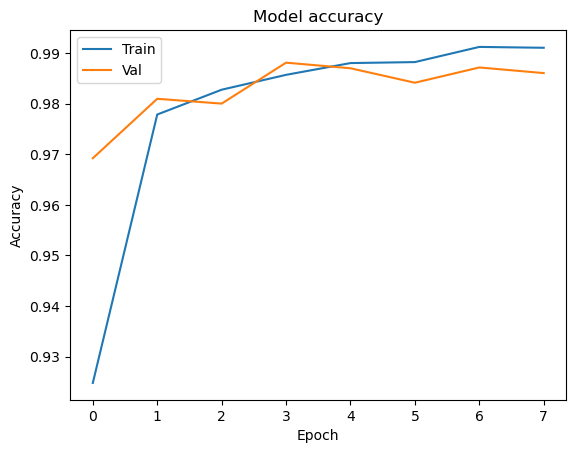

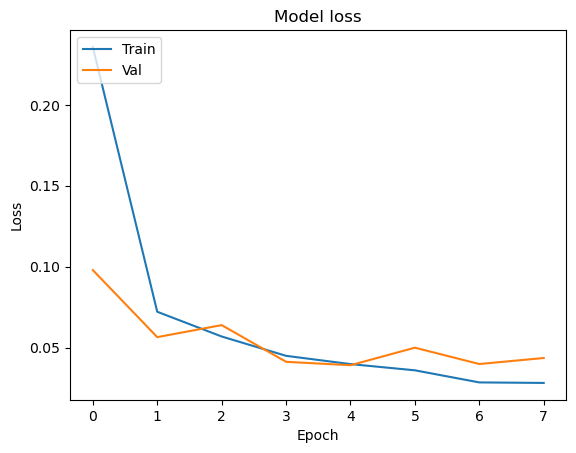

In [52]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [53]:
model3.evaluate(X_test,y_test)

197/197 [==============================] - 1s 3ms/step - loss: 0.0436 - accuracy: 0.9860


[0.04358059912919998, 0.9860317707061768]

In [54]:
# Let's increase the number of data and observe the situation;
# Veri sayısını artırıp durumu gözlemleyelim;

In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [65]:
datagen = ImageDataGenerator(
    rotation_range=10,  # rotate images randomly within 10 degrees
    zoom_range=0.1,     # zoom images randomly within 10%
    width_shift_range=0.1,  # shift images horizontally randomly within 10%
    height_shift_range=0.1, # shift images vertically randomly within 10%
    shear_range=0.1,    # shear images randomly within 10 degrees
    horizontal_flip=False, # flip images horizontally randomly
    vertical_flip=False   # flip images vertically randomly
)

# Fit the augmentation method on training set
datagen.fit(X_train)

In [66]:
history3 = model3.fit(
    datagen.flow(X_train, y_train),
    epochs=8, 
    validation_data=(X_test, y_test),
    verbose=1)

Epoch 1/8


2023-03-19 15:22:24.760805: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_5/dropout_16/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1116/1116 [==============================] - 18s 15ms/step - loss: 0.4568 - accuracy: 0.8541 - val_loss: 0.0746 - val_accuracy: 0.9759
Epoch 2/8
1116/1116 [==============================] - 15s 13ms/step - loss: 0.1424 - accuracy: 0.9578 - val_loss: 0.0488 - val_accuracy: 0.9851
Epoch 3/8
1116/1116 [==============================] - 16s 14ms/step - loss: 0.1048 - accuracy: 0.9690 - val_loss: 0.0572 - val_accuracy: 0.9832
Epoch 4/8
1116/1116 [==============================] - 15s 13ms/step - loss: 0.0884 - accuracy: 0.9730 - val_loss: 0.0437 - val_accuracy: 0.9875
Epoch 5/8
1116/1116 [==============================] - 16s 14ms/step - loss: 0.0806 - accuracy: 0.9752 - val_loss: 0.0419 - val_accuracy: 0.9870
Epoch 6/8
1116/1116 [==============================] - 15s 13ms/step - loss: 0.0738 - accuracy: 0.9778 - val_loss: 0.0390 - val_accuracy: 0.9878
Epoch 7/8
1116/1116 [==============================] - 16s 14ms/step - loss: 0.0645 - accuracy: 0.9804 - val_loss: 0.0307 - val_accuracy: 0.

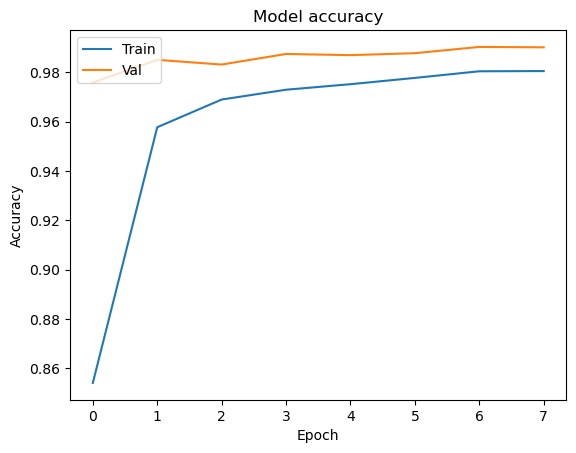

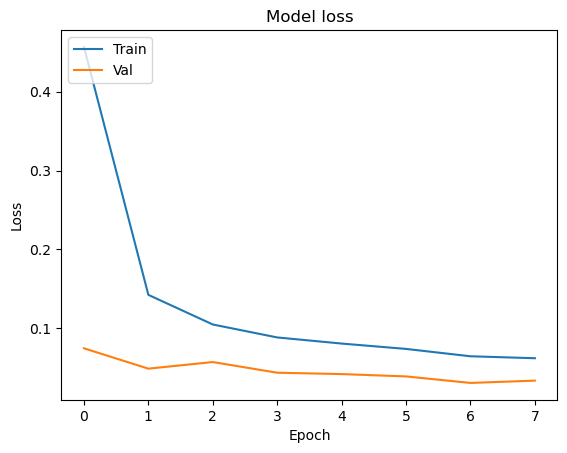

In [67]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [68]:
model3.evaluate(X_test,y_test)

197/197 [==============================] - 1s 3ms/step - loss: 0.0336 - accuracy: 0.9902


[0.0336260087788105, 0.99015873670578]

In [69]:
# we improved our success rate
#  başarı oranımızı iyileştirdik

In [71]:
# confusion matrix

In [72]:
from sklearn.metrics import confusion_matrix

197/197 [==============================] - 0s 2ms/step


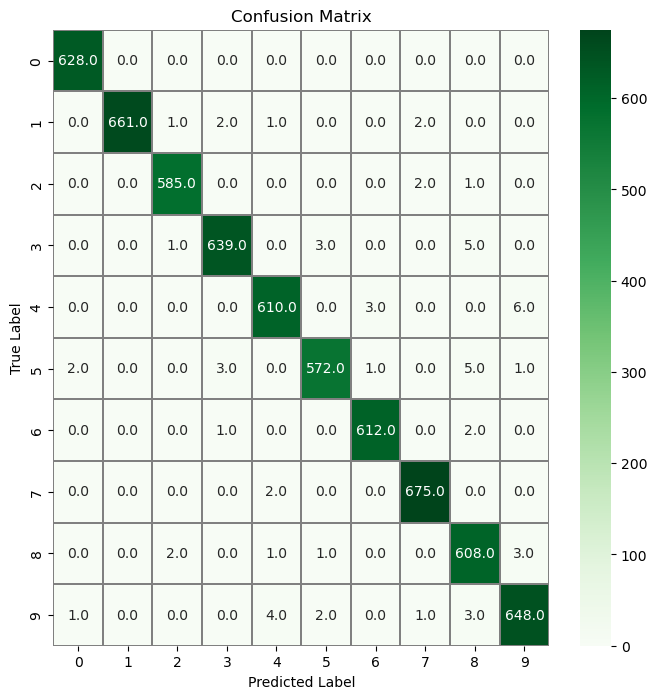

In [73]:
# confusion matrix
import seaborn as sns
Y_pred = model3.predict(X_test)
Y_pred_classes = np.argmax(Y_pred,axis = 1) 
# Convert validation observations to one hot vectors
Y_true = np.argmax(y_test,axis = 1) 
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 
# plot the confusion matrix
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="Greens",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [74]:
# we have observed how we guessed which number
# hangi rakamı nasıl tahmin ettiğimizi gözlemlemiş olduk